## Imports

In [39]:
import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.varmax import VARMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## Load Data

In [40]:
df = pd.read_csv("../data/processed/weather_clean.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df = df.set_index("timestamp")

df.head()

,temperature_c,station_pressure_hpa,sea_level_pressure_hpa,pressure_change_hpa,humidity_pct,wind_speed_ms,visibility,dew_point_c,precipitation_mm,precipitation_period_h,cloud_cover_encoded,wind_dir_sin,wind_dir_cos
timestamp,,,,,,,,,,,,,
2019-01-01 00:00:00,6.2,762.6,770.5,0.0,86.0,1.0,10.0,4.0,0.0,0.0,0.0,0.707107,-0.707107
2019-01-01 03:00:00,7.6,763.0,770.8,0.4,85.0,2.0,10.0,5.2,0.0,0.0,0.0,0.707107,-0.707107
2019-01-01 06:00:00,4.8,763.1,771.0,0.1,88.0,1.0,8.0,3.0,0.0,0.0,0.0,0.707107,-0.707107
2019-01-01 09:00:00,8.9,765.0,772.8,1.9,88.0,1.0,10.0,7.0,0.0,0.0,0.0,0.382683,-0.923880
2019-01-01 12:00:00,17.2,764.7,772.3,-0.3,51.0,1.0,10.0,7.0,0.0,0.0,0.0,-0.923880,-0.382683


## Targets

In [41]:
targets = [
    "temperature_c",
    "humidity_pct",
    "sea_level_pressure_hpa",
    "wind_speed_ms",
    "precipitation_mm"
]

## Train/Test split

In [42]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

train_endog = train[targets]
test_endog = test[targets]

In [43]:
def evaluate_model(y_true, y_pred):

    metrics = []

    for col in y_true.columns:

        mae = mean_absolute_error(
            y_true[col],
            y_pred[col]
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true[col],
                y_pred[col]
            )
        )

        r2 = r2_score(
            y_true[col],
            y_pred[col]
        )

        metrics.append([
            col,
            mae,
            rmse,
            r2
        ])

    return pd.DataFrame(
        metrics,
        columns=[
            "Variable",
            "MAE",
            "RMSE",
            "R2"
        ]
    )

## Fit Baseline VAR

In [44]:
from statsmodels.tsa.api import VAR
model = VAR(train_endog)

lag_order_results = model.select_order(maxlags=16)

print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        14.03       14.03   1.238e+06       14.03
1        8.109       8.137       3326.       8.119
2        7.575       7.626       1949.       7.593
3        7.265       7.339       1429.       7.290
4        6.950       7.047       1043.       6.983
5        6.572       6.692       714.6       6.613
6        6.407       6.550       606.1       6.456
7        6.131       6.297       460.0       6.188
8        6.009       6.198       406.9       6.074
9        5.838       6.051       343.2       5.911
10       5.799      6.034*       329.9       5.880
11       5.782       6.041       324.6       5.871
12       5.781       6.063       324.1       5.878
13       5.777       6.082       322.9       5.882
14       5.774       6.102       321.9       5.887
15       5.747       6.098       313.3       5.868
16      5.714*       6.088     

In [45]:
# model_var = VARMAX(
#     train_endog,
#     order=(10, 0)
# )

# var_results = model_var.fit(
#     maxiter=100,
#     disp=False
# )

## Train Var

In [46]:
from statsmodels.tsa.api import VAR

model_var = VAR(train_endog)

var_results = model_var.fit(10)
print(var_results.summary())

forecast_steps = 80

var_forecast = var_results.forecast(
    y=train_endog.values[-10:],
    steps=forecast_steps
)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 23, Jun, 2026
Time:                     20:42:40
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    6.03188
Nobs:                     7503.00    HQIC:                   5.87739
Log likelihood:          -74722.4    FPE:                    329.176
AIC:                      5.79659    Det(Omega_mle):         318.213
--------------------------------------------------------------------
Results for equation temperature_c
                                coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------------
const                             24.447306         6.191697            3.948           0.000
L1.temperature_c                   0.742908         0.016212           45.824           0.000


## Forecast on Test Set

In [47]:
print(var_forecast.shape)

(80, 5)


In [48]:
var_forecast = pd.DataFrame(
    var_forecast,
    index=test_endog.index[:80],
    columns=test_endog.columns
)
var_metrics = evaluate_model(
    test_endog.iloc[:80],
    var_forecast
)

print(var_metrics)

                 Variable        MAE       RMSE        R2
0           temperature_c   6.065818   6.901992 -3.536958
1            humidity_pct  10.424742  13.025637 -0.153053
2  sea_level_pressure_hpa   1.496093   1.745949 -2.564498
3           wind_speed_ms   1.349940   1.681471 -0.371770
4        precipitation_mm   2.875444   8.858018  0.000000


In [49]:
residuals = var_results.resid

residuals.head()

,temperature_c,humidity_pct,sea_level_pressure_hpa,wind_speed_ms,precipitation_mm
timestamp,,,,,
2019-01-02 06:00:00,-0.529848,-0.947288,-0.473627,0.554795,-0.042680
2019-01-02 09:00:00,-2.019754,8.727080,0.130678,-0.632209,0.640710
2019-01-02 12:00:00,2.181980,0.020548,-0.707154,-1.112155,-0.452867
2019-01-02 15:00:00,0.436509,-3.308720,-0.067373,0.897759,-0.118995
2019-01-02 18:00:00,-1.110050,-3.037780,0.458727,-0.564634,0.141279


In [50]:
residuals.shape

(7503, 5)

<Figure size 800x400 with 0 Axes>

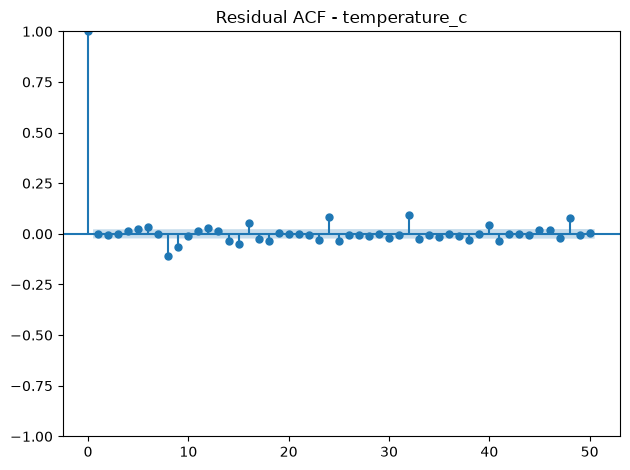

<Figure size 800x400 with 0 Axes>

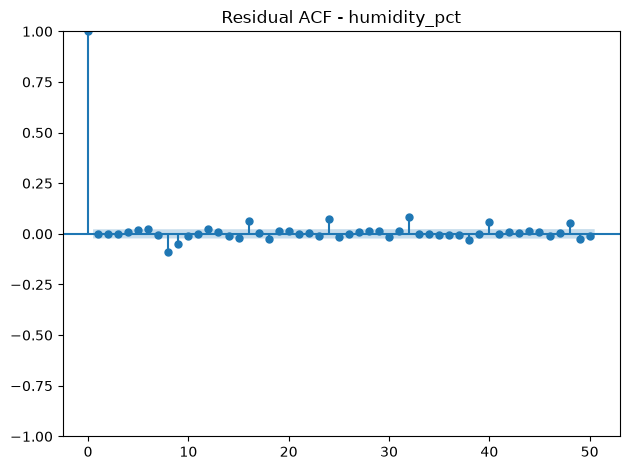

<Figure size 800x400 with 0 Axes>

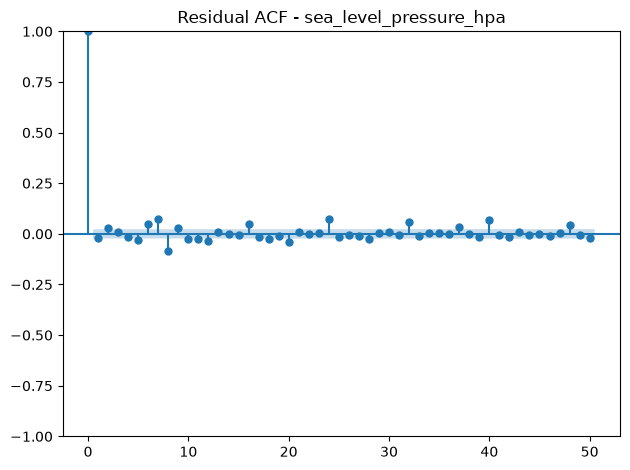

<Figure size 800x400 with 0 Axes>

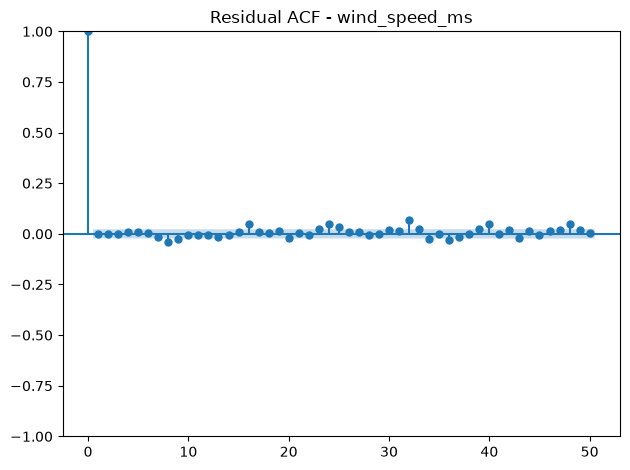

<Figure size 800x400 with 0 Axes>

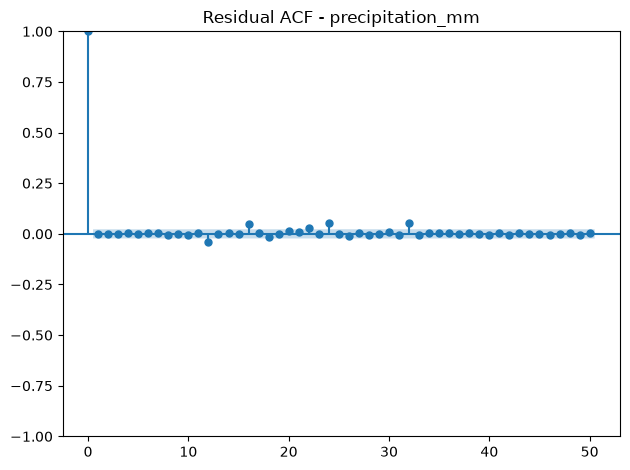

In [51]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

for col in residuals.columns:
    
    plt.figure(figsize=(8,4))
    
    plot_acf(
        residuals[col],
        lags=50,
        alpha=0.05  # 95% confidence intervals
    )
    
    plt.title(f"Residual ACF - {col}")
    plt.tight_layout()
    plt.show()

In [52]:
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in residuals.columns:
    print(f"\n{col}")
    print(acorr_ljungbox(residuals[col], lags=[24], return_df=True))


temperature_c
       lb_stat     lb_pvalue
24  268.524673  3.417933e-43

humidity_pct
       lb_stat     lb_pvalue
24  178.557003  1.381169e-25

sea_level_pressure_hpa
       lb_stat     lb_pvalue
24  233.348204  3.215376e-36

wind_speed_ms
      lb_stat  lb_pvalue
24  69.648647   0.000002

precipitation_mm
      lb_stat  lb_pvalue
24  61.170306   0.000044
